In [5]:
# imports section

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, SGDRegressor, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor


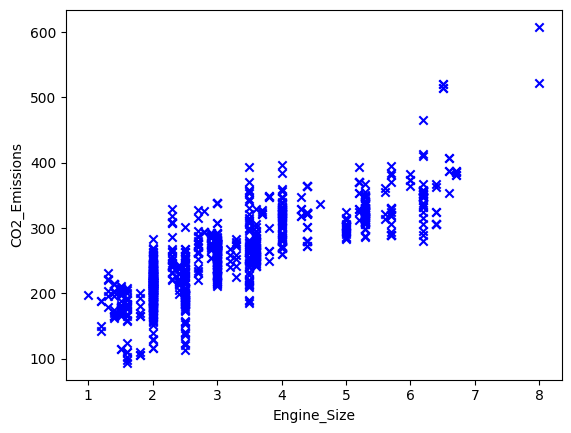

In [6]:
def build_plot(file_path, x, y):
    data = pd.read_csv(file_path)
    plt.scatter(data[x], data[y], c='blue', marker='x')
    plt.xlabel(x)
    plt.ylabel(y)
    return plt

build_plot('resources/CO2_emission.csv', 'Engine_Size', 'CO2_Emissions').show()


In [7]:
def extract_texts_from_file(file_path):
    """
    Extract the text data from the csv file

    Args:
        file_path (str): Relative location of the csv file in the project.

    Returns:
        list: The list of texts as strings.
    """
    df = pd.read_csv(file_path)
    return df.to_dict('records')

data = extract_texts_from_file('resources/heart.csv')
print(data[:50])

[{'age': 63, 'sex': 1, 'cp': 3, 'trtbps': 145, 'chol': 233, 'fbs': 1, 'restecg': 0, 'thalachh': 150, 'exng': 0, 'oldpeak': 2.3, 'slp': 0, 'caa': 0, 'thall': 1, 'output': 1}, {'age': 37, 'sex': 1, 'cp': 2, 'trtbps': 130, 'chol': 250, 'fbs': 0, 'restecg': 1, 'thalachh': 187, 'exng': 0, 'oldpeak': 3.5, 'slp': 0, 'caa': 0, 'thall': 2, 'output': 1}, {'age': 41, 'sex': 0, 'cp': 1, 'trtbps': 130, 'chol': 204, 'fbs': 0, 'restecg': 0, 'thalachh': 172, 'exng': 0, 'oldpeak': 1.4, 'slp': 2, 'caa': 0, 'thall': 2, 'output': 1}, {'age': 56, 'sex': 1, 'cp': 1, 'trtbps': 120, 'chol': 236, 'fbs': 0, 'restecg': 1, 'thalachh': 178, 'exng': 0, 'oldpeak': 0.8, 'slp': 2, 'caa': 0, 'thall': 2, 'output': 1}, {'age': 57, 'sex': 0, 'cp': 0, 'trtbps': 120, 'chol': 354, 'fbs': 0, 'restecg': 1, 'thalachh': 163, 'exng': 1, 'oldpeak': 0.6, 'slp': 2, 'caa': 0, 'thall': 2, 'output': 1}, {'age': 57, 'sex': 1, 'cp': 0, 'trtbps': 140, 'chol': 192, 'fbs': 0, 'restecg': 1, 'thalachh': 148, 'exng': 0, 'oldpeak': 0.4, 'slp': 

c:\Users\Valentyn\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=3.52107e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Valentyn\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.379e+12, tolerance: 1.540e+09
  model = cd_fast.enet_coordinate_descent(
c:\Users\Valentyn\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.383e+12, tolerance: 1.540e+09
  model =

Model Comparison for Electric Power Consumption:
RF (300 trees, depth=None)         : R**2 = 0.9285
RF (200 trees, depth=20, min_split=5): R**2 = 0.7975
RF (200 trees, depth=15)           : R**2 = 0.6950
RF (200 trees, depth=15, max_feat=sqrt): R**2 = 0.6406
RF (200 trees, depth=15, max_feat=log2): R**2 = 0.6406
RF (250 trees, depth=12, tuned)    : R**2 = 0.5166
RF (100 trees, depth=10)           : R**2 = 0.4854
Gradient Boosting                  : R**2 = 0.4251
Extra Trees                        : R**2 = 0.3911
Polynomial (degree 4)              : R**2 = 0.3160
Ridge (poly degree 4)              : R**2 = 0.3159
Polynomial (degree 3)              : R**2 = 0.3065
ElasticNet (poly degree 4)         : R**2 = 0.3017
Lasso (poly degree 4)              : R**2 = 0.3016
MLP (Neural Network)               : R**2 = 0.2968
Polynomial (degree 2)              : R**2 = 0.2883
Linear                             : R**2 = 0.2454
Ridge (linear)                     : R**2 = 0.2454
Lasso (linear)         

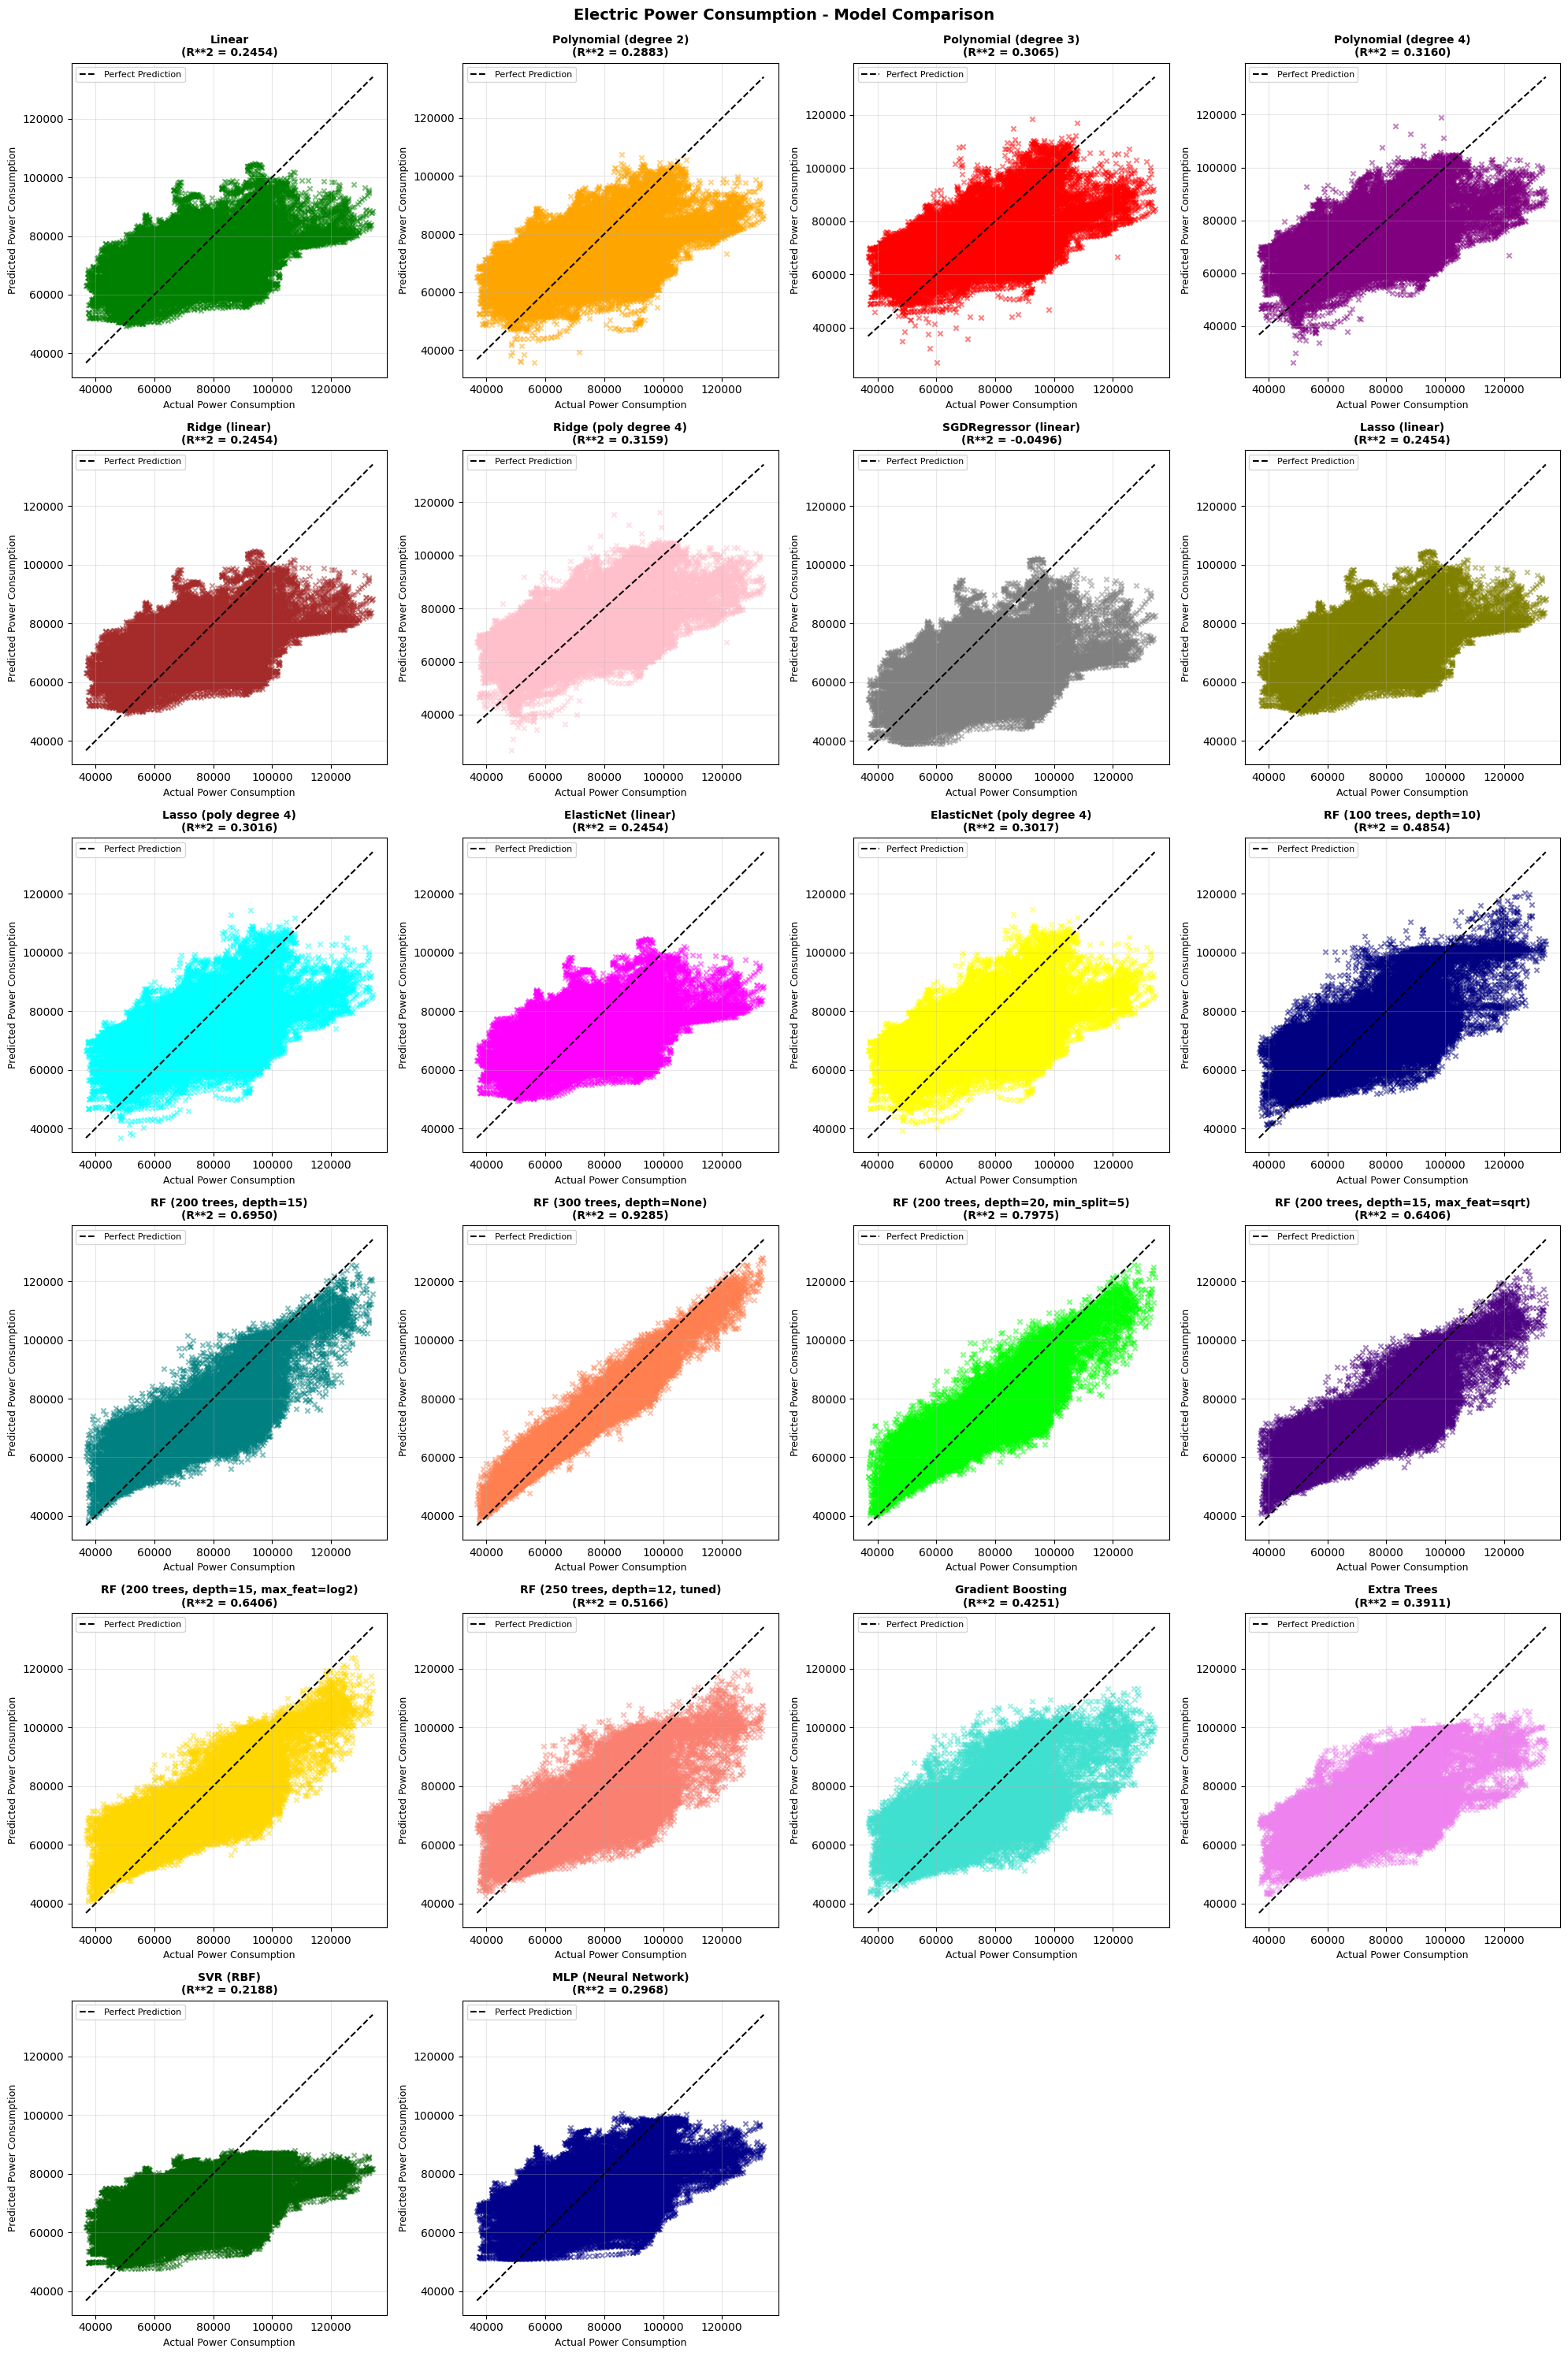

In [8]:
data_power = extract_texts_from_file('resources/powerconsumption.csv')
df_power = pd.DataFrame(data_power)

X = df_power[['Temperature', 'Humidity', 'WindSpeed']].values
y = df_power['PowerConsumption_Zone1'].values + df_power['PowerConsumption_Zone2'].values + df_power['PowerConsumption_Zone3'].values

models = {}
r2_scores = {}

linear_model = LinearRegression()
linear_model.fit(X, y)
y_pred_linear = linear_model.predict(X)
r2_linear = r2_score(y, y_pred_linear)
models['Linear'] = {'model': linear_model, 'degree': 1}
r2_scores['Linear'] = r2_linear

poly_features_2 = PolynomialFeatures(degree=2)
X_poly_2 = poly_features_2.fit_transform(X)
poly_model_2 = LinearRegression()
poly_model_2.fit(X_poly_2, y)
y_pred_poly_2 = poly_model_2.predict(X_poly_2)
r2_poly_2 = r2_score(y, y_pred_poly_2)
models['Polynomial (degree 2)'] = {'model': poly_model_2, 'degree': 2, 'poly_features': poly_features_2}
r2_scores['Polynomial (degree 2)'] = r2_poly_2

poly_features_3 = PolynomialFeatures(degree=3)
X_poly_3 = poly_features_3.fit_transform(X)
poly_model_3 = LinearRegression()
poly_model_3.fit(X_poly_3, y)
y_pred_poly_3 = poly_model_3.predict(X_poly_3)
r2_poly_3 = r2_score(y, y_pred_poly_3)
models['Polynomial (degree 3)'] = {'model': poly_model_3, 'degree': 3, 'poly_features': poly_features_3}
r2_scores['Polynomial (degree 3)'] = r2_poly_3

poly_features_4 = PolynomialFeatures(degree=4)
X_poly_4 = poly_features_4.fit_transform(X)
poly_model_4 = LinearRegression()
poly_model_4.fit(X_poly_4, y)
y_pred_poly_4 = poly_model_4.predict(X_poly_4)
r2_poly_4 = r2_score(y, y_pred_poly_4)
models['Polynomial (degree 4)'] = {'model': poly_model_4, 'degree': 4, 'poly_features': poly_features_4}
r2_scores['Polynomial (degree 4)'] = r2_poly_4

ridge_linear = Ridge(alpha=1.0, random_state=42)
ridge_linear.fit(X, y)
y_pred_ridge_linear = ridge_linear.predict(X)
r2_ridge_linear = r2_score(y, y_pred_ridge_linear)
models['Ridge (linear)'] = {'model': ridge_linear, 'degree': 1}
r2_scores['Ridge (linear)'] = r2_ridge_linear

ridge_poly = Ridge(alpha=1.0, random_state=42)
ridge_poly.fit(X_poly_4, y)
y_pred_ridge_poly = ridge_poly.predict(X_poly_4)
r2_ridge_poly = r2_score(y, y_pred_ridge_poly)
models['Ridge (poly degree 4)'] = {'model': ridge_poly, 'degree': 4, 'poly_features': poly_features_4}
r2_scores['Ridge (poly degree 4)'] = r2_ridge_poly

sgd_linear = SGDRegressor(random_state=42, max_iter=1000, tol=1e-3)
sgd_linear.fit(X, y)
y_pred_sgd_linear = sgd_linear.predict(X)
r2_sgd_linear = r2_score(y, y_pred_sgd_linear)
models['SGDRegressor (linear)'] = {'model': sgd_linear, 'degree': 1}
r2_scores['SGDRegressor (linear)'] = r2_sgd_linear

lasso_linear = Lasso(alpha=0.1, random_state=42, max_iter=1000)
lasso_linear.fit(X, y)
y_pred_lasso_linear = lasso_linear.predict(X)
r2_lasso_linear = r2_score(y, y_pred_lasso_linear)
models['Lasso (linear)'] = {'model': lasso_linear, 'degree': 1}
r2_scores['Lasso (linear)'] = r2_lasso_linear

lasso_poly = Lasso(alpha=0.1, random_state=42, max_iter=1000)
lasso_poly.fit(X_poly_4, y)
y_pred_lasso_poly = lasso_poly.predict(X_poly_4)
r2_lasso_poly = r2_score(y, y_pred_lasso_poly)
models['Lasso (poly degree 4)'] = {'model': lasso_poly, 'degree': 4, 'poly_features': poly_features_4}
r2_scores['Lasso (poly degree 4)'] = r2_lasso_poly

elastic_linear = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42, max_iter=1000)
elastic_linear.fit(X, y)
y_pred_elastic_linear = elastic_linear.predict(X)
r2_elastic_linear = r2_score(y, y_pred_elastic_linear)
models['ElasticNet (linear)'] = {'model': elastic_linear, 'degree': 1}
r2_scores['ElasticNet (linear)'] = r2_elastic_linear

elastic_poly = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42, max_iter=1000)
elastic_poly.fit(X_poly_4, y)
y_pred_elastic_poly = elastic_poly.predict(X_poly_4)
r2_elastic_poly = r2_score(y, y_pred_elastic_poly)
models['ElasticNet (poly degree 4)'] = {'model': elastic_poly, 'degree': 4, 'poly_features': poly_features_4}
r2_scores['ElasticNet (poly degree 4)'] = r2_elastic_poly

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X, y)
y_pred_rf = rf_model.predict(X)
r2_rf = r2_score(y, y_pred_rf)
models['RF (100 trees, depth=10)'] = {'model': rf_model, 'degree': 1}
r2_scores['RF (100 trees, depth=10)'] = r2_rf

rf_model_1 = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_model_1.fit(X, y)
y_pred_rf_1 = rf_model_1.predict(X)
r2_rf_1 = r2_score(y, y_pred_rf_1)
models['RF (200 trees, depth=15)'] = {'model': rf_model_1, 'degree': 1}
r2_scores['RF (200 trees, depth=15)'] = r2_rf_1

rf_model_2 = RandomForestRegressor(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)
rf_model_2.fit(X, y)
y_pred_rf_2 = rf_model_2.predict(X)
r2_rf_2 = r2_score(y, y_pred_rf_2)
models['RF (300 trees, depth=None)'] = {'model': rf_model_2, 'degree': 1}
r2_scores['RF (300 trees, depth=None)'] = r2_rf_2

rf_model_3 = RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_split=5, min_samples_leaf=2, random_state=42, n_jobs=-1)
rf_model_3.fit(X, y)
y_pred_rf_3 = rf_model_3.predict(X)
r2_rf_3 = r2_score(y, y_pred_rf_3)
models['RF (200 trees, depth=20, min_split=5)'] = {'model': rf_model_3, 'degree': 1}
r2_scores['RF (200 trees, depth=20, min_split=5)'] = r2_rf_3

rf_model_4 = RandomForestRegressor(n_estimators=200, max_depth=15, max_features='sqrt', random_state=42, n_jobs=-1)
rf_model_4.fit(X, y)
y_pred_rf_4 = rf_model_4.predict(X)
r2_rf_4 = r2_score(y, y_pred_rf_4)
models['RF (200 trees, depth=15, max_feat=sqrt)'] = {'model': rf_model_4, 'degree': 1}
r2_scores['RF (200 trees, depth=15, max_feat=sqrt)'] = r2_rf_4

rf_model_5 = RandomForestRegressor(n_estimators=200, max_depth=15, max_features='log2', random_state=42, n_jobs=-1)
rf_model_5.fit(X, y)
y_pred_rf_5 = rf_model_5.predict(X)
r2_rf_5 = r2_score(y, y_pred_rf_5)
models['RF (200 trees, depth=15, max_feat=log2)'] = {'model': rf_model_5, 'degree': 1}
r2_scores['RF (200 trees, depth=15, max_feat=log2)'] = r2_rf_5

rf_model_6 = RandomForestRegressor(n_estimators=250, max_depth=12, min_samples_split=4, min_samples_leaf=1, max_features='sqrt', random_state=42, n_jobs=-1)
rf_model_6.fit(X, y)
y_pred_rf_6 = rf_model_6.predict(X)
r2_rf_6 = r2_score(y, y_pred_rf_6)
models['RF (250 trees, depth=12, tuned)'] = {'model': rf_model_6, 'degree': 1}
r2_scores['RF (250 trees, depth=12, tuned)'] = r2_rf_6

gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_model.fit(X, y)
y_pred_gb = gb_model.predict(X)
r2_gb = r2_score(y, y_pred_gb)
models['Gradient Boosting'] = {'model': gb_model, 'degree': 1}
r2_scores['Gradient Boosting'] = r2_gb

et_model = ExtraTreesRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
et_model.fit(X, y)
y_pred_et = et_model.predict(X)
r2_et = r2_score(y, y_pred_et)
models['Extra Trees'] = {'model': et_model, 'degree': 1}
r2_scores['Extra Trees'] = r2_et

svr_model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr_model.fit(X, y)
y_pred_svr = svr_model.predict(X)
r2_svr = r2_score(y, y_pred_svr)
models['SVR (RBF)'] = {'model': svr_model, 'degree': 1}
r2_scores['SVR (RBF)'] = r2_svr

mlp_model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42, early_stopping=True, validation_fraction=0.1)
mlp_model.fit(X, y)
y_pred_mlp = mlp_model.predict(X)
r2_mlp = r2_score(y, y_pred_mlp)
models['MLP (Neural Network)'] = {'model': mlp_model, 'degree': 1}
r2_scores['MLP (Neural Network)'] = r2_mlp

print("Model Comparison for Electric Power Consumption:")
print("=" * 70)
for model_name, score in sorted(r2_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:35s}: R**2 = {score:.4f}")
print("=" * 70)

best_model_name = max(r2_scores.items(), key=lambda x: x[1])[0]
best_r2 = r2_scores[best_model_name]
print(f"\nBest model: {best_model_name} with R**2 = {best_r2:.4f}")

num_models = len(models)
cols = 4
rows = (num_models + cols - 1) // cols  

plt.figure(figsize=(20, 5 * rows))

colors = ['green', 'orange', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 
          'cyan', 'magenta', 'yellow', 'navy', 'teal', 'coral', 'lime', 'indigo',
          'gold', 'salmon', 'turquoise', 'violet', 'darkgreen', 'darkblue', 
          'darkred', 'darkorange', 'darkviolet', 'darkcyan', 'darkmagenta']

for idx, (model_name, model_info) in enumerate(models.items()):
    if model_info['degree'] == 1:
        y_pred = model_info['model'].predict(X)
    else:
        X_pred_poly = model_info['poly_features'].transform(X)
        y_pred = model_info['model'].predict(X_pred_poly)
    
    plt.subplot(rows, cols, idx + 1)
    plt.scatter(y, y_pred, alpha=0.5, c=colors[idx % len(colors)], marker='x', s=20)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', linewidth=1.5, label='Perfect Prediction')
    plt.xlabel('Actual Power Consumption', fontsize=9)
    plt.ylabel('Predicted Power Consumption', fontsize=9)
    plt.title(f'{model_name}\n(R**2 = {r2_scores[model_name]:.4f})', fontsize=10, fontweight='bold')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)

plt.suptitle('Electric Power Consumption - Model Comparison', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()